# Classificatin - Siniflandirma

Classification cevabi evet veya positive,negative, notr gibi olan modellerde kullanilir.  
Bu prijede binlerce calisani olan bir sirket calisanlarinin isten ayrilip ayrilmayacagini tahmin eden bir model gelistirecegiz.

In [2]:
import pandas as pd
pd.set_option('display.max_columns', 100)

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

In [3]:
df = pd.read_csv('hr_data.csv')
df.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,2,5993.0,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,Yes
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,1,5130.0,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,No
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,2,2090.0,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,Yes
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,1,2909.0,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,No
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,1,3468.0,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,No


### EDA - Exploratory Data Analysis

In [4]:
df.sample()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
1150,35,Travel_Rarely,819,Research & Development,18,5,Life Sciences,1,1621,2,Male,48,4,2,Research Scientist,1,1,5208.0,26312,1,Y,No,11,3,4,80,0,16,2,3,16,15,1,10,No


In [5]:
df.isnull().sum()

Age                           0
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance               0
YearsAtCompany                0
YearsInC

<Axes: xlabel='Attrition', ylabel='count'>

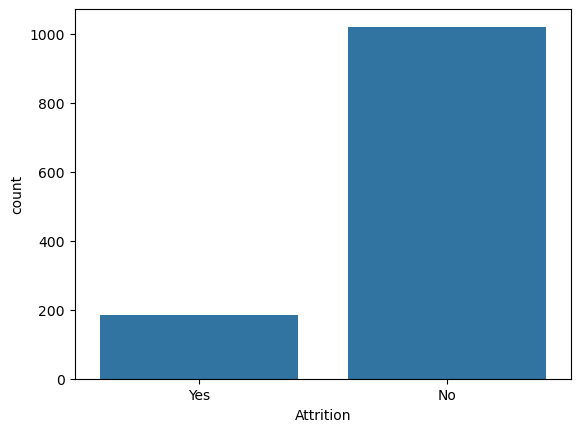

In [6]:
sns.countplot(x='Attrition', data=df)

In [7]:
df['Attrition'].unique()

array(['Yes', 'No', nan], dtype=object)

In [8]:
df.shape

(1470, 35)

<Axes: xlabel='Attrition', ylabel='count'>

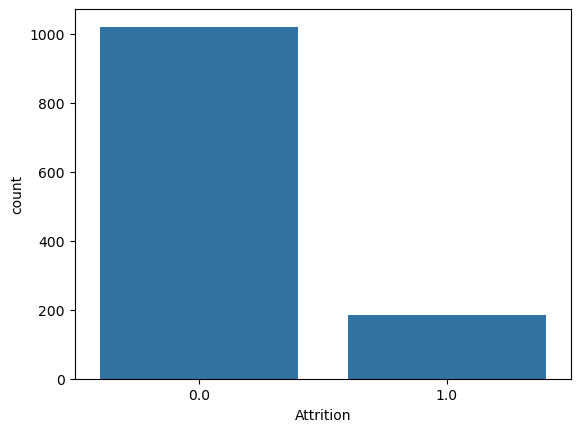

In [9]:
d  = {'No' : 0 , 'Yes' : 1}
df['Attrition'] = df['Attrition'].map(d)
sns.countplot(x= df['Attrition'])

In [10]:
bos = df[df['Attrition'].isnull()] 
dolu = df[df['Attrition'].notnull()]
dolu.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,2,5993.0,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,1.0
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,1,5130.0,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,0.0
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,2,2090.0,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,1.0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,1,2909.0,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0,0.0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,1,3468.0,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2,0.0


In [11]:
bos.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
367,50,Travel_Rarely,1046,Research & Development,10,3,Technical Degree,1,491,4,Male,100,2,3,Healthcare Representative,4,2,9587.987822,2755,6,Y,No,15,3,4,80,0,20,2,3,4,3,1,3,NaN
368,40,Travel_Rarely,575,Sales,22,2,Marketing,1,492,3,Male,68,2,2,Sales Executive,3,1,5910.500884,6110,2,Y,Yes,12,3,1,80,2,8,6,3,6,4,1,0,NaN
369,31,Travel_Rarely,408,Research & Development,9,4,Life Sciences,1,493,3,Male,42,2,1,Research Scientist,2,2,2611.940519,7551,0,Y,Yes,16,3,4,80,0,3,5,3,2,2,2,2,NaN
370,21,Travel_Rarely,156,Sales,12,3,Life Sciences,1,494,3,Female,90,4,1,Sales Representative,2,2,1963.485226,25422,1,Y,No,15,3,4,80,0,1,0,3,1,0,0,0,NaN
371,29,Travel_Rarely,1283,Research & Development,23,3,Life Sciences,1,495,4,Male,54,3,1,Research Scientist,4,2,2761.033309,18168,9,Y,No,16,3,4,80,0,6,4,3,3,2,1,2,NaN


In [12]:
x = dolu.drop('Attrition', axis=1)
y = dolu[['Attrition']]

x.sample()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
324,30,Travel_Rarely,1275,Research & Development,28,2,Medical,1,441,4,Female,64,3,2,Research Scientist,4,1,5775.0,11934,1,Y,No,13,3,4,80,2,11,2,3,10,8,1,9


In [13]:
x = pd.get_dummies(x, drop_first=True)
x.shape

(1205, 46)

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB

In [16]:
g  = GaussianNB()
b = BernoulliNB()

In [17]:
g.fit(x_train, y_train)

GaussianNB()

In [18]:
b.fit(x_train, y_train)

BernoulliNB()

In [19]:
tahmin_g = g.predict(x_test)

In [20]:
tahmin_b = b.predict(x_test)

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [22]:
accuracy_score(y_test, tahmin_g)

0.7883817427385892

In [23]:
confusion_matrix(y_test, tahmin_g)

array([[171,  40],
       [ 11,  19]])

In [24]:
print(classification_report(y_test, tahmin_g))

              precision    recall  f1-score   support

         0.0       0.94      0.81      0.87       211
         1.0       0.32      0.63      0.43        30

    accuracy                           0.79       241
   macro avg       0.63      0.72      0.65       241
weighted avg       0.86      0.79      0.82       241



<Axes: >

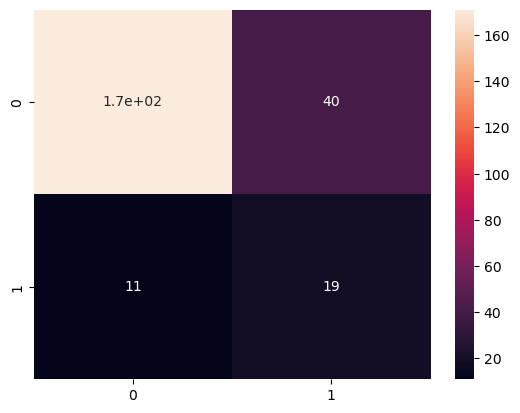

In [25]:
sns.heatmap(confusion_matrix(y_test, tahmin_g), annot=True)

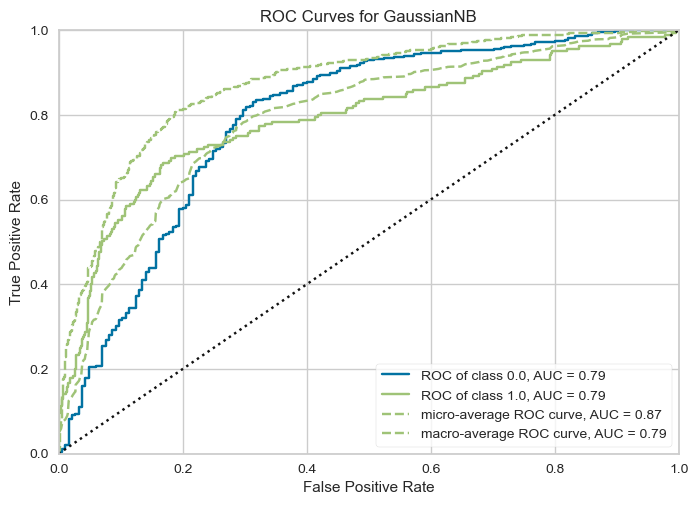

In [26]:
from yellowbrick.classifier import roc_auc
from yellowbrick.datasets import load_spam

visualizerGNB = roc_auc(GaussianNB(),x ,y)

In [27]:
accuracy_score(y_test, tahmin_b)

0.8257261410788381

In [28]:
confusion_matrix(y_test, tahmin_b)

array([[192,  19],
       [ 23,   7]])

In [29]:
print(classification_report(y_test, tahmin_b))

              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90       211
         1.0       0.27      0.23      0.25        30

    accuracy                           0.83       241
   macro avg       0.58      0.57      0.58       241
weighted avg       0.82      0.83      0.82       241



<Axes: >

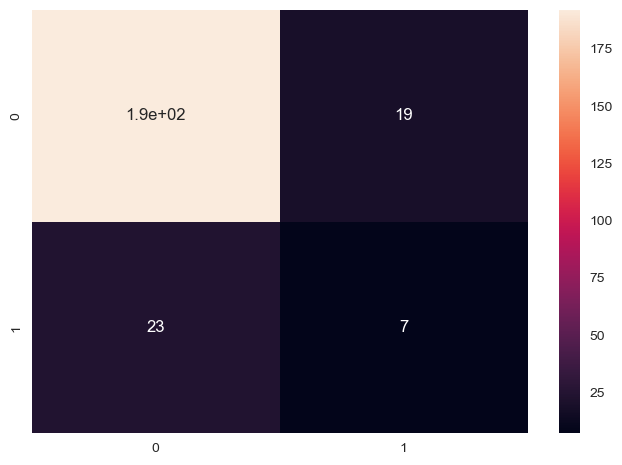

In [30]:
sns.heatmap(confusion_matrix(y_test, tahmin_b), annot=True)

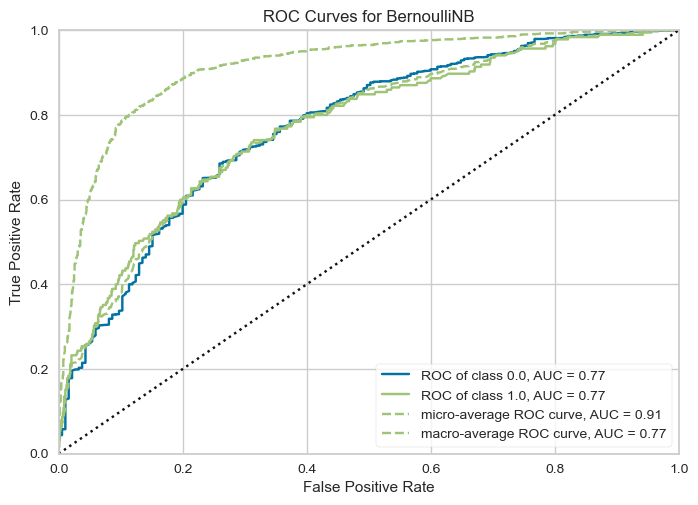

In [31]:
visualizerBRN = roc_auc(BernoulliNB(),x ,y)

In [32]:
from sklearn.linear_model import LogisticRegression

L = LogisticRegression()

In [33]:
L.fit(x_train, y_train)

LogisticRegression()

In [34]:
tahmin_L = L.predict(x_test)

In [35]:
accuracy_score(y_test, tahmin_L)

0.8672199170124482

In [36]:
confusion_matrix(y_test, tahmin_L)

array([[209,   2],
       [ 30,   0]])

In [37]:
print(classification_report(y_test, tahmin_L))

              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93       211
         1.0       0.00      0.00      0.00        30

    accuracy                           0.87       241
   macro avg       0.44      0.50      0.46       241
weighted avg       0.77      0.87      0.81       241



<Axes: >

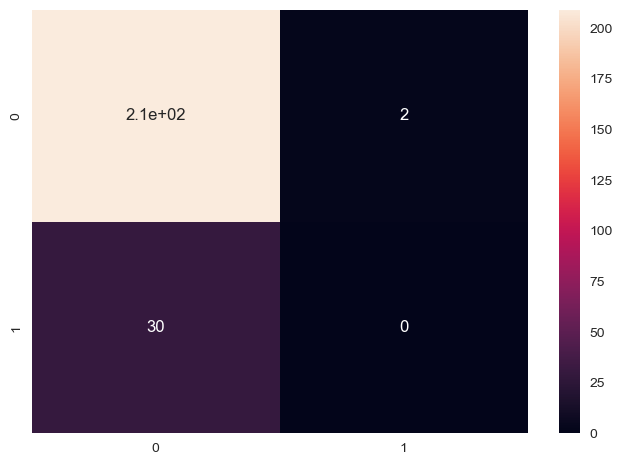

In [38]:
sns.heatmap(confusion_matrix(y_test, tahmin_L), annot=True)

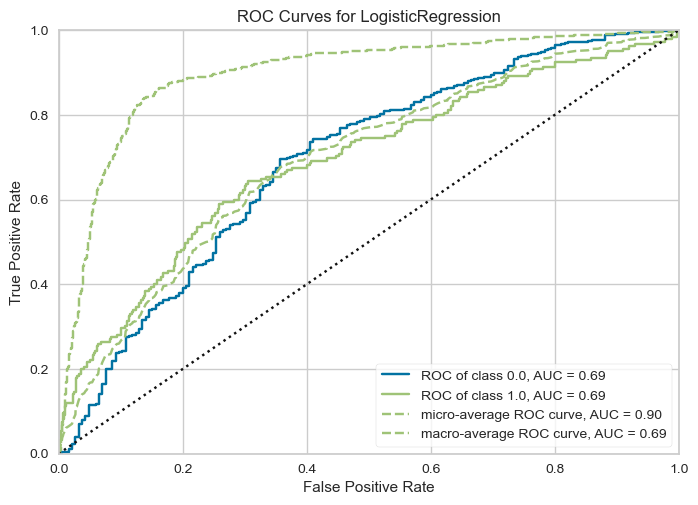

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for LogisticRegression'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       estimator=LogisticRegression())

In [39]:
roc_auc(L,x ,y)

In [40]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
d = DecisionTreeClassifier()

In [42]:
d.fit(x_train, y_train)

DecisionTreeClassifier()

In [43]:
tahmin_d = d.predict(x_test)

In [44]:
accuracy_score(y_test, tahmin_d)

0.7883817427385892

In [45]:
confusion_matrix(y_test, tahmin_d)

array([[181,  30],
       [ 21,   9]])

In [46]:
print(classification_report(y_test, tahmin_d))

              precision    recall  f1-score   support

         0.0       0.90      0.86      0.88       211
         1.0       0.23      0.30      0.26        30

    accuracy                           0.79       241
   macro avg       0.56      0.58      0.57       241
weighted avg       0.81      0.79      0.80       241



<Axes: >

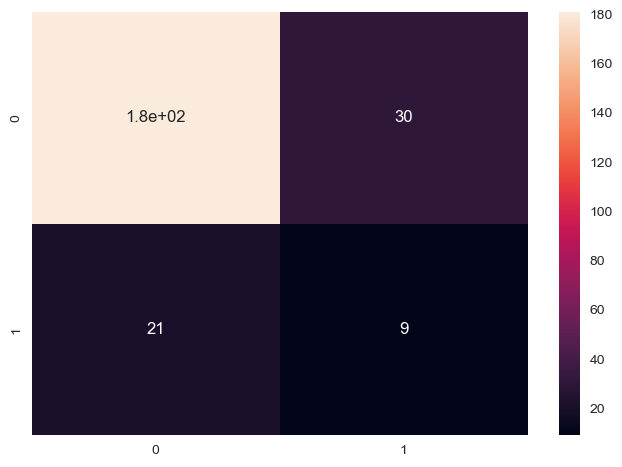

In [47]:
sns.heatmap(confusion_matrix(y_test, tahmin_d), annot=True)

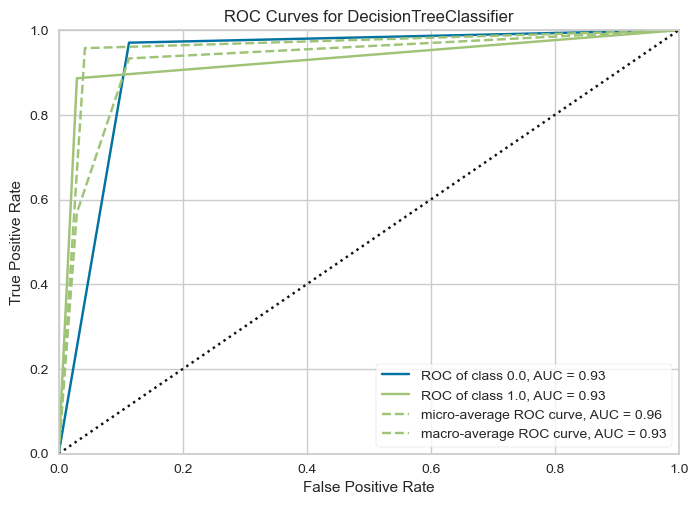

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for DecisionTreeClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       estimator=DecisionTreeClassifier())

In [48]:
roc_auc(d,x ,y)

In [49]:
from sklearn.ensemble import RandomForestClassifier

In [50]:
r = RandomForestClassifier()

In [51]:
r.fit(x_train, y_train)

RandomForestClassifier()

In [52]:
tahmin_r = r.predict(x_test)

In [53]:
accuracy_score(y_test, tahmin_r)

0.8796680497925311

In [54]:
confusion_matrix(y_test, tahmin_r)

array([[210,   1],
       [ 28,   2]])

In [55]:
print(classification_report(y_test, tahmin_r))

              precision    recall  f1-score   support

         0.0       0.88      1.00      0.94       211
         1.0       0.67      0.07      0.12        30

    accuracy                           0.88       241
   macro avg       0.77      0.53      0.53       241
weighted avg       0.86      0.88      0.83       241



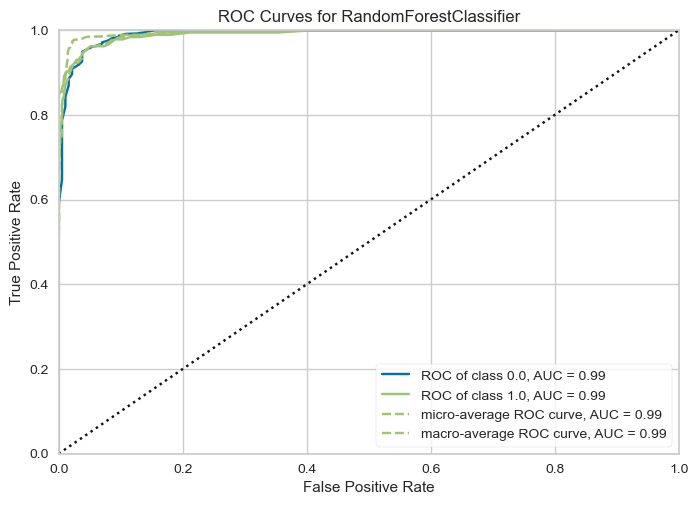

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for RandomForestClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       estimator=RandomForestClassifier())

In [56]:
roc_auc(r,x ,y)

In [57]:
from sklearn.neighbors import KNeighborsClassifier

In [58]:
N = KNeighborsClassifier()

In [59]:
N.fit(x_train, y_train)

KNeighborsClassifier()

In [60]:
tahmin_N = N.predict(x_test)

In [61]:
accuracy_score(y_test, tahmin_N)

0.8547717842323651

In [62]:
confusion_matrix(y_test, tahmin_N)

array([[205,   6],
       [ 29,   1]])

In [63]:
print(classification_report(y_test, tahmin_N))

              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92       211
         1.0       0.14      0.03      0.05        30

    accuracy                           0.85       241
   macro avg       0.51      0.50      0.49       241
weighted avg       0.78      0.85      0.81       241



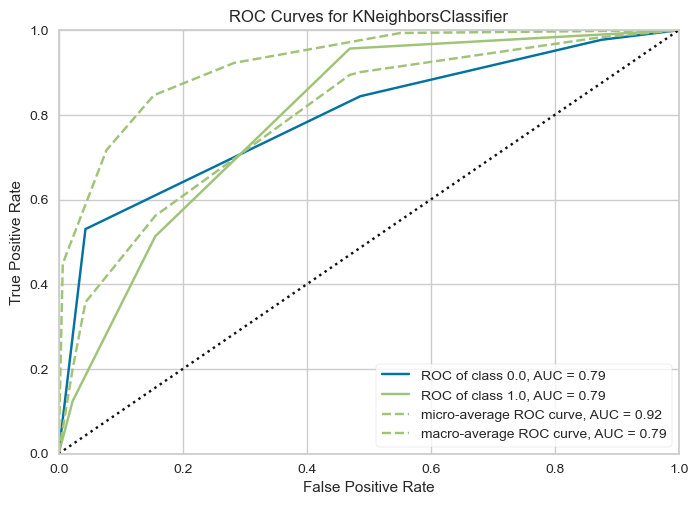

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for KNeighborsClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       estimator=KNeighborsClassifier())

In [64]:
roc_auc(N,x ,y)

In [65]:
from sklearn.ensemble import GradientBoostingClassifier

In [66]:
h = GradientBoostingClassifier()

In [67]:
tahmin_h = h.fit(x_train, y_train).predict(x_test)

In [68]:
accuracy_score(y_test, tahmin_h)

0.8879668049792531

In [69]:
confusion_matrix(y_test, tahmin_h)

array([[208,   3],
       [ 24,   6]])

In [70]:
print(classification_report(y_test, tahmin_h))

              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94       211
         1.0       0.67      0.20      0.31        30

    accuracy                           0.89       241
   macro avg       0.78      0.59      0.62       241
weighted avg       0.87      0.89      0.86       241



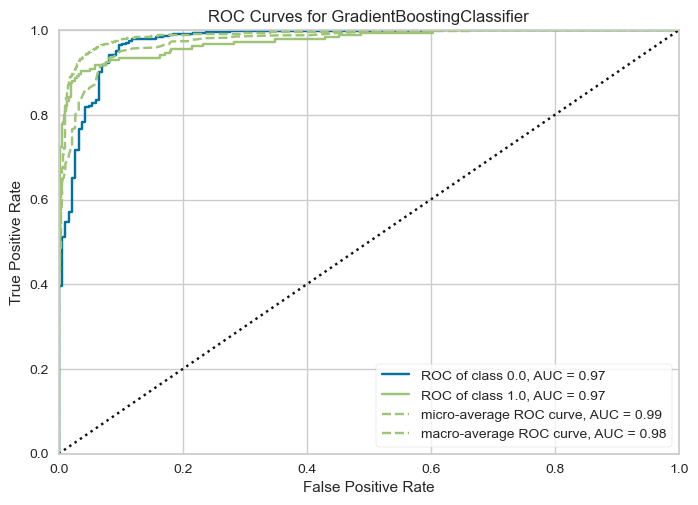

ROCAUC(ax=<Axes: title={'center': 'ROC Curves for GradientBoostingClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>,
       estimator=GradientBoostingClassifier())

In [71]:
roc_auc(h,x ,y)

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [73]:
algo_test(x, y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[192  19]
 [ 23   7]]
LogisticRegression()  modeli eğitiliyor!..
[[209   2]
 [ 30   0]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[178  33]
 [ 22   8]]
RandomForestClassifier()  modeli eğitiliyor!..
[[210   1]
 [ 28   2]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[208   3]
 [ 24   6]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[205   6]
 [ 29   1]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[203   8]
 [ 19  11]]
MultinomialNB()  modeli eğitiliyor!..
[[115  96]
 [  9  21]]
Eğitim tamamlandı.
En başarılı model:  GradientBoostingClassifier
Confusion Matrix:
[[208   3]
 [ 24   6]]
classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94       211
         1.0       0.67      0.20      0.31        30

    accuracy                           0.89       241
   macro avg       0.78      0.59      0.62       241
weighted avg       0.87      0.

,Accuracy,Precision,Recall,F1
GradientBoostingClassifier,0.887967,0.887967,0.887967,0.887967
AdaBoostClassifier,0.887967,0.887967,0.887967,0.887967
RandomForestClassifier,0.879668,0.879668,0.879668,0.879668
LogisticRegression,0.867220,0.867220,0.867220,0.867220
KNeighborsClassifier,0.854772,0.854772,0.854772,0.854772
BernoulliNB,0.825726,0.825726,0.825726,0.825726
DecisionTreeClassifier,0.771784,0.771784,0.771784,0.771784
MultinomialNB,0.564315,0.564315,0.564315,0.564315
